In [10]:
!pip install matplotlib

You should consider upgrading via the 'C:\Users\User\Documents\TKU\大二AI實驗下\DL_ai\Scripts\python.exe -m pip install --upgrade pip' command.


In [11]:
!pip install thop

You should consider upgrading via the 'C:\Users\User\Documents\TKU\大二AI實驗下\DL_ai\Scripts\python.exe -m pip install --upgrade pip' command.


### 1.參數實驗

#### 捲積核對於計算量

In [12]:
import torch
import torch.nn as nn
from thop import profile #計算量估計

1.一般捲積

In [13]:
class NormalBlock(nn.Module):
    def __init__(self, in_channel, out_channel):
        super().__init__()
        self.conv = nn.Conv2d(in_channel, out_channel, kernel_size=5, padding=2)
    
    def forward(self, x):
        return self.conv(x)

2.Inception block

In [14]:
class InceptionOriginal(nn.Module):
    def __init__(self, inchannel):
        super().__init__()
        self.b1 = nn.Conv2d(inchannel, 32, kernel_size=1)
        self.b2 = nn.Conv2d(inchannel, 32, kernel_size=3, padding=1)
        self.b3 = nn.Conv2d(inchannel, 32, kernel_size=5, padding=2)
        self.b4 = nn.MaxPool2d(3, stride=1, padding=1)
        self.b4_conv = nn.Conv2d(inchannel, 32, kernel_size=1)

    #串聯網路 (Parallel)
    def forward(self, x):
        return torch.cat([self.b1(x), self.b2(x), self.b3(x), self.b4_conv(self.b4(x))], 1)

3.GoogleNet改良版

In [15]:
class GoogleInception(nn.Module):
    def __init__(self, in_channel):
        super().__init__()
        self.b1 = nn.Conv2d(in_channel, 32, kernel_size=1)
        self.b2 = nn.Sequential(
            nn.Conv2d(in_channel, 16,kernel_size=1),
            nn.Conv2d(16, 32, kernel_size=3, padding=1)
        )
        self.b3 = nn.Sequential(
            nn.Conv2d(in_channel, 16, kernel_size=1),
            nn.Conv2d(16, 32, kernel_size=5, padding=2)
        )
        self.b4 = nn.Sequential(
            nn.MaxPool2d(3, stride=1, padding=1),
            nn.Conv2d(in_channel, 32, kernel_size=1)
        )

    def forward(self, x):
        return torch.cat([self.b1(x), self.b2(x), self.b3(x),self.b4(x)], 1)

實驗時間~~~

In [16]:
input_data = torch.randn(1, 64, 28, 28)

models = [
    ("NormalBlock", NormalBlock(64, 128)),
    ("InceptionOriginal", InceptionOriginal(64)),
    ("GoogleInception", GoogleInception(64))
]
print(f"{'架構名稱':<30} | {'參數 (Params)':<15} | {'運算量 (FLOPs)':<15}")
for name, model in models:
    flops, params = profile(model, inputs =(input_data, ),verbose=False)
    print(f"{name:<33} | {params:<17.0f} | {flops/1e6:} M")

架構名稱                           | 參數 (Params)     | 運算量 (FLOPs)    
NormalBlock                       | 204928            | 160.5632 M
InceptionOriginal                 | 73856             | 57.802752 M
GoogleInception                   | 23712             | 18.464768 M


#### Overfitting

1.資料量太少

In [63]:
#為了方便模組化，會將模型拆成 1.features(卷積) 2.classifier(分類用的全連接層)
import torch.nn as nn
class AlexNet(nn.Module):
    def __init__(self, in_channels=3, num_classes=1000):
        super(AlexNet, self).__init__()
        #1. features
        self.features = nn.Sequential(
            #conv1:
            nn.Conv2d(in_channels, 96, kernel_size=3, stride=1, padding=1), #224x224 -> 55x55
            nn.ReLU(inplace=True),#激活函數：擬合非線性複雜資料 f(x) = max(0, x)
            nn.MaxPool2d(kernel_size=3, stride=2), #55x55 -> 27x27

            #conv2(same padding):
            nn.Conv2d(96, 256, kernel_size=5, padding=2), #27x27 -> 27x27
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2), #27x27 -> 13x13
            #conv3(same padding), 4(same padding), 5:
            nn.Conv2d(256, 384, kernel_size=3, padding=1), #13x13 -> 13x13
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 384, kernel_size=3, padding=1), #13x13 -> 13x13
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 256, kernel_size=3, padding=1), #13x13 -> 13x13
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2), # #13x13 -> 6x6
        )
        self.avgpool = nn.AdaptiveAvgPool2d((3, 3))
        self.classifier = nn.Sequential(
            #nn.Dropout(p=0.5), #prevent overfitting : 關閉特定神經元，讓剩下的學會提取特徵
            #nn.Linear(256 * 6 * 6, 4096),
            nn.Linear(256 * 3 * 3, 1024),
            nn.ReLU(inplace=True),
            #nn.Dropout(p=0.5),
            nn.Linear(1024, 512),
            #nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            #nn.Linear(4096, num_classes),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return(x)

In [64]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 定義資料轉換流程
transform = transforms.Compose([
    #transforms.Resize(224),           
    transforms.ToTensor(),          
    transforms.Normalize(            
        mean=[0.485, 0.456, 0.406], 
        std=[0.229, 0.224, 0.225]
    )
])

train_set = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_set = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

In [77]:
from torch.utils.data import Subset

# 製作子資料集
train_subset = Subset(train_set, range(50000))
test_subset = Subset(test_set, range(10000))

train_loader = DataLoader(train_subset, batch_size=10, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=10, shuffle=False)
print(f"訓練子集數量: {len(train_subset)}")

訓練子集數量: 50000


100%|██████████| 5000/5000 [00:35<00:00, 140.94it/s]


Epoch 1:Loss: 1.6607 | Train Acc: 37.73% | Test Acc: 44.77%


100%|██████████| 5000/5000 [00:34<00:00, 143.47it/s]


Epoch 2:Loss: 1.3302 | Train Acc: 52.37% | Test Acc: 55.61%


100%|██████████| 5000/5000 [00:34<00:00, 144.68it/s]


...

Epoch 98:Loss: 0.0010 | Train Acc: 99.98% | Test Acc: 74.23%


100%|██████████| 5000/5000 [00:34<00:00, 144.38it/s]


Epoch 99:Loss: 0.0013 | Train Acc: 99.97% | Test Acc: 73.88%


100%|██████████| 5000/5000 [00:34<00:00, 144.23it/s]


Epoch 100:Loss: 0.0016 | Train Acc: 99.98% | Test Acc: 73.96%


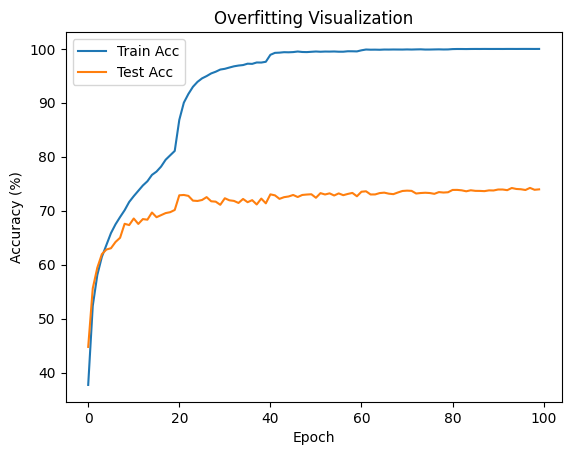

In [78]:
import matplotlib.pyplot as plt
import torch
import torch.optim as optim
from torchvision import models
import torch.nn as nn
from tqdm import tqdm

train_acc_his = []
test_acc_his = []

model = AlexNet(num_classes=10).cuda()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)
criterion = nn.CrossEntropyLoss()

# 2. 訓練循環 (觀察 Loss 和 Acc)
for epoch in range(100):
    model.train()
    train_loss, train_correct = 0, 0
    for images, labels in tqdm(train_loader):
        images, labels = images.cuda(), labels.cuda()
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        optimizer.zero_grad()
        loss.backward()
        #
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # ← 加這行
        #
        optimizer.step()
        
        train_loss += loss.item()
        _, predicted = outputs.max(1)
        train_correct += predicted.eq(labels).sum().item()
    
    model.eval()
    test_correct = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.cuda(), labels.cuda()
            outputs = model(images)
            _, predicted = outputs.max(1)
            test_correct += predicted.eq(labels).sum().item()

    print(f"Epoch {epoch+1}:Loss: {train_loss/len(train_loader):.4f} | Train Acc: {100.*train_correct/len(train_subset):.2f}% | Test Acc: {100.*test_correct/len(test_subset):.2f}%")
    # ... 在 Epoch 結束後 ...
    train_acc_his.append(100.*train_correct/len(train_subset))
    test_acc_his.append(100.*test_correct/len(test_subset))

    #
    scheduler.step()
    # 

# 訓練結束後畫圖
plt.plot(train_acc_his, label='Train Acc')
plt.plot(test_acc_his, label='Test Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.title('Overfitting Visualization')
plt.show()

In [ ]:
total_params = sum(p.numel() for p in model.parameters())
classifier_params = sum(p.numel() for p in model.classifier.parameters())
print(f"總參數量: {total_params:,}")
print(f"分類器參數佔比: {100 * classifier_params / total_params:.2f}%")

總參數量: 58,322,314
分類器參數佔比: 93.58%


2.訓練時間太久